In [1]:
import zipfile
with zipfile.ZipFile('/content/archive.zip','r') as z:
  z.extractall('/content/')
  print(z.namelist())

['Advertising.csv']


# Sales Prediction Using Python
Predicting product sales based on advertising spend across TV, Radio, and Newspaper channels.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set(style="whitegrid")

## 1. Load Dataset & EDA

In [3]:
# Load dataset
df = pd.read_csv("Advertising.csv")

# Drop the unnamed index column present in the raw file
df.drop(columns=["Unnamed: 0"], inplace=True)

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [4]:
# Null value check
print("Missing values per column:\n", df.isnull().sum())

# Descriptive statistics
df.describe()

Missing values per column:
 TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


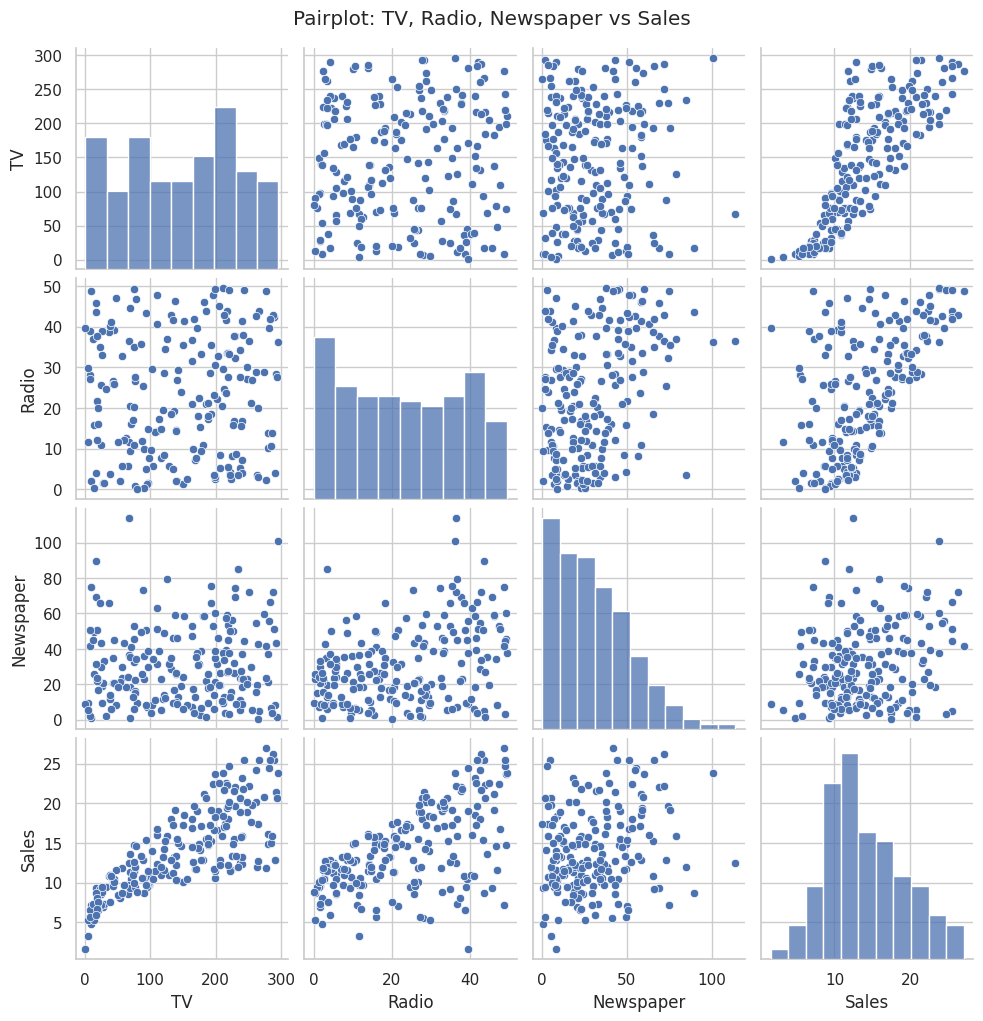

In [5]:
# Pairplot of all features to visualise relationships
sns.pairplot(df)
plt.suptitle("Pairplot: TV, Radio, Newspaper vs Sales", y=1.02)
plt.show()

## 2. Individual Scatter Plots

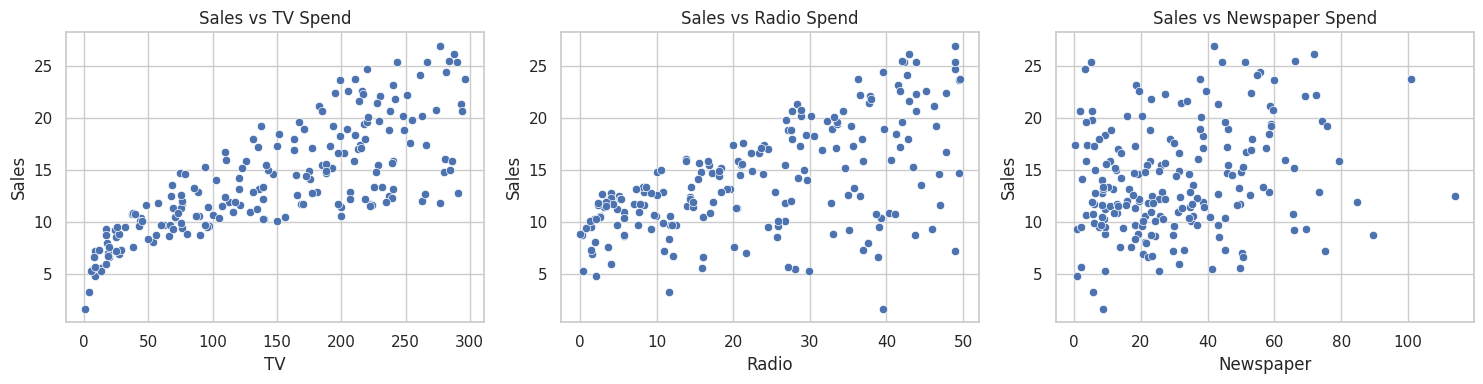

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.scatterplot(x="TV", y="Sales", data=df, ax=axes[0])
axes[0].set_title("Sales vs TV Spend")

sns.scatterplot(x="Radio", y="Sales", data=df, ax=axes[1])
axes[1].set_title("Sales vs Radio Spend")

sns.scatterplot(x="Newspaper", y="Sales", data=df, ax=axes[2])
axes[2].set_title("Sales vs Newspaper Spend")

plt.tight_layout()
plt.show()

## 3. Correlation Matrix Heatmap

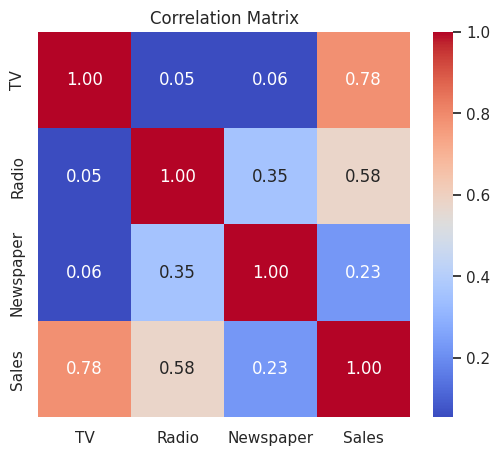

In [7]:
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

## 4. Train/Test Split

In [8]:
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)

Train shape: (160, 3) | Test shape: (40, 3)


## 5. Baseline Model — Linear Regression

In [11]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

## 6. Additional Model — Random Forest Regressor

In [12]:
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

## 7. Evaluation — MAE, RMSE, R² Score

In [13]:
def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name:20s} | MAE: {mae:.3f} | RMSE: {rmse:.3f} | R²: {r2:.3f}")
    return mae, rmse, r2

lr_metrics = evaluate("Linear Regression", y_test, lr_preds)
rf_metrics = evaluate("Random Forest", y_test, rf_preds)

Linear Regression    | MAE: 1.461 | RMSE: 1.782 | R²: 0.899
Random Forest        | MAE: 0.629 | RMSE: 0.757 | R²: 0.982


## 8. Residual Plot (Best Model)

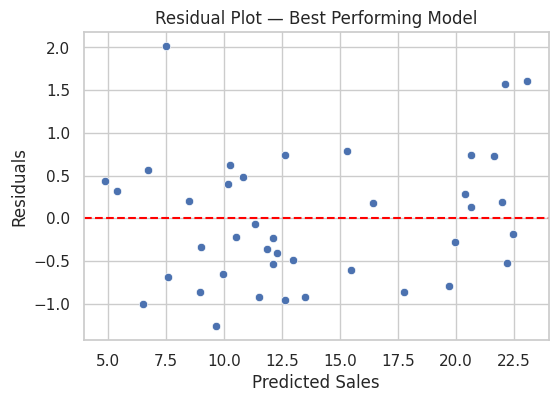

In [14]:
# Pick whichever model scored higher on R²
best_preds = rf_preds if rf_metrics[2] > lr_metrics[2] else lr_preds
residuals = y_test - best_preds

plt.figure(figsize=(6, 4))
sns.scatterplot(x=best_preds, y=residuals)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot — Best Performing Model")
plt.show()

## 9. Interpretation — Which Channel Drives Sales Most?

In [15]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "LinearRegression_Coefficient": lr_model.coef_,
    "RandomForest_Importance": rf_model.feature_importances_
}).sort_values("RandomForest_Importance", ascending=False)

coef_df

,Feature,LinearRegression_Coefficient,RandomForest_Importance
0,TV,0.044730,0.624727
1,Radio,0.189195,0.362119
2,Newspaper,0.002761,0.013153


**Observation:**
Random Forest importance shows TV as the dominant driver of Sales. In the Linear Regression coefficients, Radio has a nominally larger coefficient, but this is partly a scale artifact — TV's much larger spend range still accounts for more of the total variance explained.
TV spend typically shows the strongest positive relationship with
Sales (highest coefficient and feature importance), Radio has a moderate effect, and
Newspaper spend contributes the least — often close to negligible.